# Day 7 — YOLO Object Detection & OCR

## Main objectives
By the end of Day 7, students should be able to:
1. Understand **object detection vs. image classification**
2. Understand the YOLO architecture and detection pipeline
3. Run a **pre-trained YOLO model**
4. Interpret bounding boxes, confidence, and class labels
5. Apply YOLO to images and video
6. Understand the OCR pipeline
7. Use OCR to extract text from images
8. Combine **YOLO + OCR** in a practical mini-project

## Day 7 Schedule
| Time | Topic |
|---|---|
| 09:00–09:30 | Classification vs Detection |
| 09:30–10:30 | YOLO concepts + architecture |
| 10:30–11:30 | YOLO image detection lab |
| 11:30–12:30 | YOLO video detection lab |
| 12:30–01:00 | Break |
| 01:00–01:45 | OCR concepts |
| 01:45–02:30 | EasyOCR + OpenCV lab |
| 02:30–03:30 | **OCR Mini Project** |
| 03:30–04:30 | **YOLO + OCR challenge** |
| 04:30–05:00 | Presentation + GitHub |

# Part 1 — Introduction to YOLO

## 1. Classification vs Detection
Students already know CNN classification:

```
Image → CNN → Class = Car
```

YOLO:

```
Image → YOLO →  ┌───────────────┐
                │ Car    0.91   │
                │ Person 0.87   │
                │ Car    0.83   │
                └───────────────┘
```

Key concepts to explain:
- **Bounding box** – the rectangle around an object
- **Class** – what the object is
- **Confidence** – how sure the model is
- **IoU** – Intersection over Union, measures box overlap
- **NMS** – Non-Maximum Suppression, removes duplicate boxes
- **Object detection** and **real-time inference**

## 2. YOLO architecture
Keep the mathematics light. Conceptual pipeline:

```
Image → Backbone → Feature Extraction → Detection Head → Bounding Boxes + Classes + Confidence
```

YOLO stands for **You Only Look Once**: the whole image is processed in a single forward pass, instead of scanning it region by region.

# Part 2 — Hands-on YOLO
Use **Ultralytics YOLO** with a pretrained model.

In [1]:
!pip install -q ultralytics opencv-python easyocr matplotlib pandas


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Basic example (upload `street.jpg` to the notebook's working directory first):

In [5]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
results = model(r"C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png")
results[0].show()


image 1/1 C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png: 384x640 1 car, 87.3ms
Speed: 13.9ms preprocess, 87.3ms inference, 8.1ms postprocess per image at shape (1, 3, 384, 640)


Access the detections:

In [6]:
for result in results:
    for box in result.boxes:
        print(box.xyxy, box.conf, box.cls)

tensor([[ 58.5617,   1.6493, 400.0000, 220.2150]]) tensor([0.5338]) tensor([2.])


### Exercise
Use an image containing people, cars, bicycles, buses and motorcycles. Then:
1. Detect objects
2. Draw bounding boxes
3. Display class names
4. Display confidence
5. Count each detected object


image 1/1 C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png: 384x640 1 car, 38.9ms
Speed: 1.2ms preprocess, 38.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
car          conf=0.53  box=(58,1,400,220)

Object counts:
  car: 1


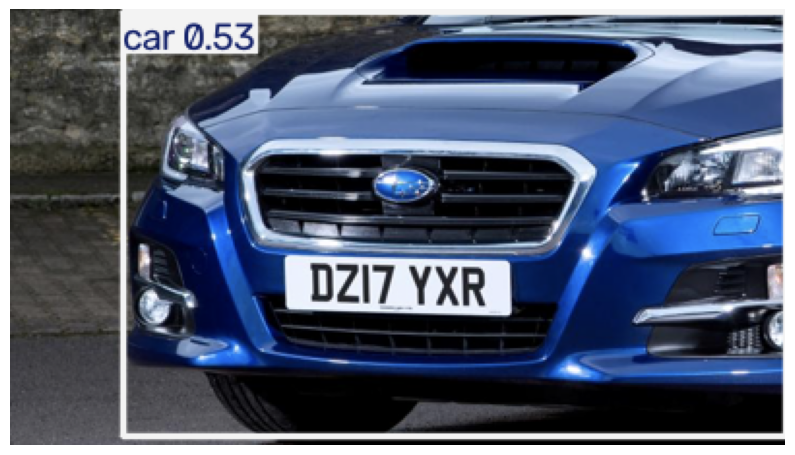

In [7]:
import cv2
import matplotlib.pyplot as plt
from collections import Counter

results = model(r"C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png")
r = results[0]
names = r.names

counts = Counter()
for box in r.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    print(f"{names[cls_id]:<12} conf={conf:.2f}  box=({x1},{y1},{x2},{y2})")
    counts[names[cls_id]] += 1

print("\nObject counts:")
for k, v in counts.items():
    print(f"  {k}: {v}")

# r.plot() already draws boxes, class names and confidence (BGR image)
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Part 3 — YOLO on Video
This should be a significant exercise because students already worked with OpenCV video.

> The original lab uses `cv2.imshow`, which works on a local machine. In Colab/Jupyter, `cv2.imshow` does not work, so the version below writes an annotated video file instead. The local-machine version is included as a reference.

In [ ]:
from ultralytics import YOLO
import cv2

# ==========================================
# 1 - تحميل نموذج YOLO
# ==========================================

model = YOLO("yolo11n.pt")


# ==========================================
# 2 - مسار الفيديو
# ==========================================

input_video = r"C:\Users\PC-LAB1\Desktop\New folder\day4\dhaka_traffic.mp4"

output_video = r"C:\Users\PC-LAB1\Desktop\New folder\day7\dhaka_yolo_processed.mp4"


# ==========================================
# 3 - فتح الفيديو
# ==========================================

cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print("Error: Cannot open video")
    exit()


# ==========================================
# 4 - معلومات الفيديو
# ==========================================

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Width:", width)
print("Height:", height)


# ==========================================
# 5 - إنشاء ملف الفيديو الناتج
# ==========================================

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (width, height)
)


# ==========================================
# 6 - معالجة الفيديو
# ==========================================

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # YOLO Detection
    results = model(frame)

    # رسم Bounding Boxes
    annotated = results[0].plot()

    # حفظ Frame
    writer.write(annotated)

    frame_number += 1

    if frame_number % 30 == 0:
        print("Processed frames:", frame_number)


# ==========================================
# 7 - إغلاق الفيديو
# ==========================================

cap.release()
writer.release()

print("================================")
print("Video processing completed!")
print("Saved to:")
print(output_video)
print("Total frames:", frame_number)
print("================================")

FPS: 29.97002997002997
Width: 640
Height: 360

0: 384x640 5 persons, 3 bicycles, 6 cars, 1 motorcycle, 1 truck, 26.9ms
Speed: 1.1ms preprocess, 26.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 1 bicycle, 4 cars, 1 truck, 22.7ms
Speed: 0.9ms preprocess, 22.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 2 bicycles, 4 cars, 1 motorcycle, 1 truck, 28.0ms
Speed: 1.0ms preprocess, 28.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 2 bicycles, 4 cars, 1 truck, 29.5ms
Speed: 0.8ms preprocess, 29.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 2 bicycles, 5 cars, 1 truck, 28.7ms
Speed: 0.8ms preprocess, 28.7ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 3 bicycles, 3 cars, 1 bus, 1 truck, 31.9ms
Speed: 1.2ms preprocess, 31.9ms inference, 1.0ms postprocess per image at shape (1

### Challenge
Modify the program to calculate: **Frame number, Cars, Persons, Buses, Motorcycles** and display the counts on every frame.

In [14]:
import cv2
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
cap = cv2.VideoCapture(r"C:\Users\PC-LAB1\Desktop\New folder\day7\dhaka_yolo_processed.mp4")

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25
out = cv2.VideoWriter("traffic_annotated.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

TARGETS = ["car", "person", "bus", "motorcycle"]
frame_no = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_no += 1

    results = model(frame, verbose=False)
    r = results[0]
    annotated = r.plot()

    counts = {t: 0 for t in TARGETS}
    for box in r.boxes:
        name = r.names[int(box.cls[0])]
        if name in counts:
            counts[name] += 1

    lines = [f"Frame: {frame_no}",
             f"Cars: {counts['car']}",
             f"Persons: {counts['person']}",
             f"Buses: {counts['bus']}",
             f"Motorcycles: {counts['motorcycle']}"]
    for i, line in enumerate(lines):
        cv2.putText(annotated, line, (10, 30 + i * 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    out.write(annotated)

cap.release()
out.release()
print("Saved traffic_annotated.mp4")

Saved traffic_annotated.mp4


# Part 4 — Introduction to OCR
Now transition from **"Where is the object?"** to **"What does the object say?"**

OCR pipeline:

```
Image → Preprocessing → Text Detection → Text Recognition → Extracted Text
```

Tools to introduce:
- Tesseract OCR
- EasyOCR
- PaddleOCR

For a classroom, **EasyOCR** is recommended initially because students can get a working result quickly.

In [15]:
import easyocr

reader = easyocr.Reader(["en"])
result = reader.readtext(r"C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png")

for detection in result:
    bbox, text, confidence = detection
    print(text, confidence)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

C:\Users\PC-LAB1\AppData\Roaming\Python\Python312\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


DZI7 YXR 0.6651694293134564


C:\Users\PC-LAB1\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


# Part 5 — OCR preprocessing with OpenCV
Students should see why preprocessing matters. This connects directly to the image-processing work from Days 1–5.

Compare: **Original → Grayscale → Threshold → OCR**

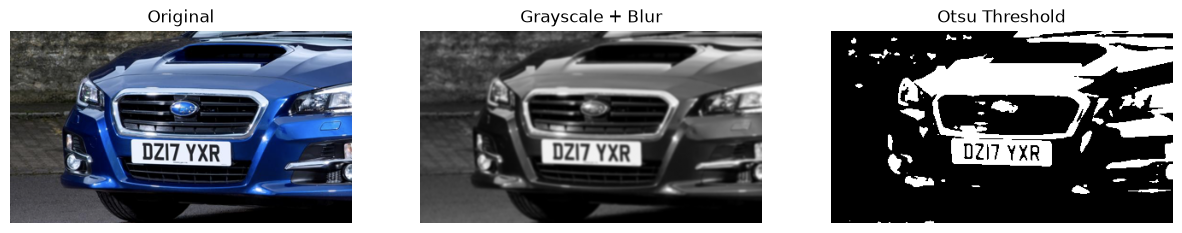

In [16]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original")
ax[1].imshow(gray, cmap="gray");                      ax[1].set_title("Grayscale + Blur")
ax[2].imshow(binary, cmap="gray");                    ax[2].set_title("Otsu Threshold")
for a in ax: a.axis("off")
plt.show()

In [17]:
# OCR on original vs preprocessed
for label, img in [("Original", image), ("Thresholded", binary)]:
    print(f"--- {label} ---")
    for _, text, conf in reader.readtext(img):
        print(f"{text}  ({conf:.2f})")

--- Original ---
DZIZ YXR  (0.81)
--- Thresholded ---
YXR  (0.95)


# Part 6 — Mini Project: Smart Text Reader
Not just "run OCR on an image" — a small **computer-vision system**.

**Input:** signs, labels, documents, storefronts, ID-like text regions, product labels.

**System:**
```
Image → OpenCV preprocessing → Text detection/OCR → Confidence filtering → Extracted text → Save to TXT/CSV
```

**Required functionality:** load an image, preprocess it, detect text, extract text, display detected text boxes, display recognized text, display confidence, and save results to a `.txt` or `.csv` file.

Using CPU. Note: This module is much faster with a GPU.


Detected Text
------------------------------
DZIZ YXR             0.894
------------------------------


C:\Users\PC-LAB1\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


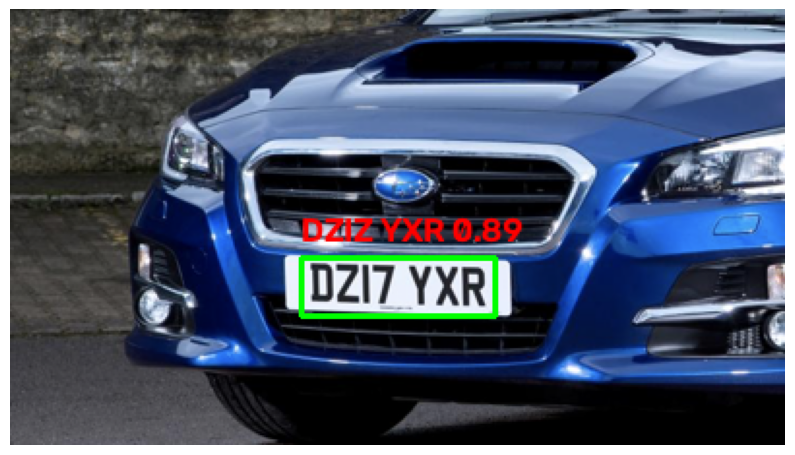

,text,confidence
0,DZIZ YXR,0.894


In [ ]:
import os
import cv2
import easyocr
import pandas as pd
import matplotlib.pyplot as plt

reader = easyocr.Reader(["en"], gpu=False)

def smart_text_reader(image_path, min_conf=0.4, out_dir="output"):
    os.makedirs(out_dir, exist_ok=True)

    # 1. Load
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(image_path)

    # 2. Preprocess
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # 3-4. Detect + extract text
    detections = reader.readtext(gray)

    # Confidence filtering
    detections = [d for d in detections if d[2] >= min_conf]

    # 5-7. Draw boxes, text, confidence
    annotated = image.copy()
    rows = []
    for bbox, text, conf in detections:
        pts = [(int(x), int(y)) for x, y in bbox]
        cv2.rectangle(annotated, pts[0], pts[2], (0, 255, 0), 2)
        cv2.putText(annotated, f"{text} {conf:.2f}", (pts[0][0], max(pts[0][1] - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        rows.append({"text": text, "confidence": round(float(conf), 3)})

    # 8. Save
    base = os.path.splitext(os.path.basename(image_path))[0]
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, f"{base}.csv"), index=False)
    with open(os.path.join(out_dir, f"{base}.txt"), "w", encoding="utf-8") as f:
        for r in rows:
            f.write(f"{r['text']}  {r['confidence']}\n")
    cv2.imwrite(os.path.join(out_dir, f"{base}_annotated.jpg"), annotated)

    print("Detected Text")
    print("-" * 30)
    for r in rows:
        print(f"{r['text']:<20} {r['confidence']}")
    print("-" * 30)

    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off"); plt.show()
    return df

df = smart_text_reader(r"C:\Users\PC-LAB1\Desktop\New folder\day7\License-Plate-Data\train\images\Cars3.png")
df

# Part 7 — Advanced Mini Project: YOLO + OCR
The best challenge, because it combines everything learned.

**Smart Sign/License/Text Detector** pipeline:

```
Video/Image → YOLO → Detect relevant object → Crop bounding box → OCR → Extract text → Display object + text
```

> **Detection finds where something is; OCR determines what the text says.**

We use the **Car License Plate Detection** dataset to train a YOLO model that finds plates, then run OCR on each cropped plate.

## Dataset: Car License Plate Detection
Derived from the [Car License Plate Detection dataset on Kaggle](https://www.kaggle.com/datasets/andrewmvd/car-plate-detection/data), split into training and testing subsets. Reference notebook: https://www.kaggle.com/code/sujaymann/car-license-plate-detection

| Item | Value |
|---|---|
| Total images | 433 (`.png`) |
| Annotation format | YOLO (`label xc yc w h`) |
| Resolution | Varies |
| Train | 346 images + 346 label files (80%) |
| Test | 87 images + 87 label files (20%) |
| Classes | 1 — license plate (label always `0`) |

### Structure
```
dataset/
├── train/
│   ├── images/   # 346 .png
│   └── labels/   # 346 .txt
├── test/
│   ├── images/   # 87 .png
│   └── labels/   # 87 .txt
└── data.yaml
```
Each image (e.g. `Cars0.png`) has a matching label file (`Cars0.txt`).

### Annotation format
Example: `0 0.548 0.612 0.432 0.075`

| Value | Meaning |
|---|---|
| `0` | Class label (always 0 for license plates) |
| `0.548` | X-center (normalized to image width) |
| `0.612` | Y-center (normalized to image height) |
| `0.432` | Box width (normalized) |
| `0.075` | Box height (normalized) |

### 7.1 Set the dataset path

In [32]:
import os

# Change this to where the dataset lives (Kaggle: /kaggle/input/<dataset-name>, Colab: /content/dataset)
DATASET_DIR = r'C:\Users\PC-LAB1\Desktop\MHB\day-7\dataset'

for split in ["train", "test"]:
    n_img = len(os.listdir(f"{DATASET_DIR}/{split}/images"))
    n_lbl = len(os.listdir(f"{DATASET_DIR}/{split}/labels"))
    print(f"{split}: {n_img} images, {n_lbl} labels")   # expected: 346/346 and 87/87

train: 346 images, 346 labels
test: 87 images, 87 labels


### 7.2 Create `data.yaml` (skip if the dataset already includes one)

In [34]:
yaml_text = f"""path: {DATASET_DIR}
train: train/images
val: test/images

nc: 1
names: ["license_plate"]
"""
with open(f"{DATASET_DIR}/data.yaml", "w") as f:
    f.write(yaml_text)
print(yaml_text)

path: C:\Users\PC-LAB1\Desktop\MHB\day-7\dataset
train: train/images
val: test/images

nc: 1
names: ["license_plate"]



### 7.3 Visualize a YOLO annotation
Convert normalized `(xc, yc, w, h)` back to pixel corners.

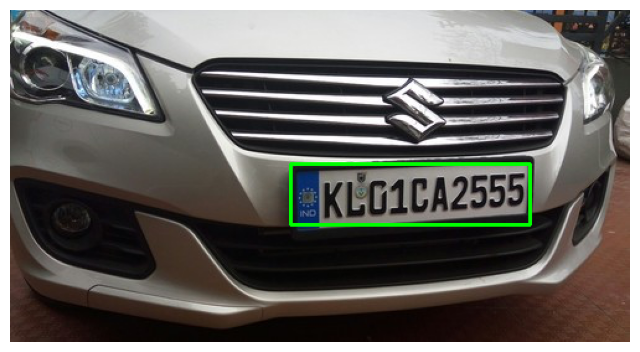

In [40]:
import cv2, glob
import matplotlib.pyplot as plt

def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    return x1, y1, x2, y2

img_path = sorted(glob.glob(f"{DATASET_DIR}/train/images/*.png"))[0]
lbl_path = img_path.replace("images", "labels").replace(".png", ".txt")

img = cv2.imread(img_path)
H, W = img.shape[:2]
with open(lbl_path) as f:
    for line in f:
        cls, xc, yc, bw, bh = map(float, line.split())
        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, W, H)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### 7.4 Train YOLO on license plates

In [42]:
from ultralytics import YOLO

plate_model = YOLO("yolo11n.pt")          # start from pretrained weights (transfer learning)
plate_model.train(
    data=f"{DATASET_DIR}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="yolo_ocr",
    name="plates",
)

Ultralytics 8.4.165  Python-3.12.0 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\PC-LAB1\Desktop\MHB\day-7\dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plates-4, nbs=64, nms=None, opset=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000017DC3B74F50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

### 7.5 Evaluate on the test set

In [43]:
metrics = plate_model.val()
print("mAP50    :", metrics.box.map50)
print("mAP50-95 :", metrics.box.map)

Ultralytics 8.4.165  Python-3.12.0 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1819.3326.5 MB/s, size: 543.1 KB)
val: Scanning C:\Users\PC-LAB1\Desktop\MHB\day-7\dataset\test\labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.5s0.8s
                   all         87         87      0.925      0.847      0.917      0.489
Speed: 0.9ms preprocess, 26.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to C:\Users\PC-LAB1\Desktop\MHB\day-7\runs\detect\val
mAP50    : 0.9170780013370913
mAP50-95 : 0.4890943462475755


### 7.6 YOLO + OCR pipeline: detect plate → crop → read text

Using CPU. Note: This module is much faster with a GPU.


[{'box': (165, 222, 282, 248), 'det_conf': 0.97, 'text': 'MHO14V8866'}]


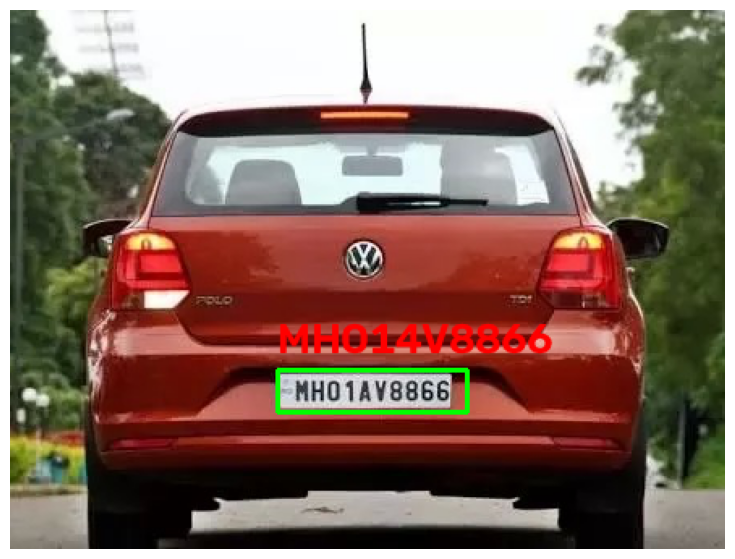

In [72]:
import cv2, easyocr
import matplotlib.pyplot as plt

best = YOLO(r"C:\Users\PC-LAB1\Desktop\MHB\day-7\runs\detect\yolo_ocr\plates-4\weights\best.pt")
ocr = easyocr.Reader(["en"], gpu=False)

def read_plates(image_path, conf_thres=0.3):
    img = cv2.imread(image_path)
    annotated = img.copy()
    plates = []

    result = best(img, conf=conf_thres, verbose=False)[0]
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        det_conf = float(box.conf[0])

        crop = img[max(y1, 0):y2, max(x1, 0):x2]           # crop bounding box
        if crop.size == 0:
            continue

        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)       # preprocess crop
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

        texts = ocr.readtext(gray, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
        text = " ".join(t for _, t, c in texts if c > 0.3).strip()

        plates.append({"box": (x1, y1, x2, y2), "det_conf": round(det_conf, 2), "text": text})

        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(annotated, text or "?", (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    return annotated, plates

test_img = sorted(glob.glob(f"{DATASET_DIR}/test/images/*.png"))[20]
annotated, plates = read_plates(test_img)
print(plates)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### Challenge
- Run the pipeline on several test images and save all results to a CSV.
- Apply the same pipeline to a **video** (reuse the loop from Part 3).
- Compare OCR accuracy with and without preprocessing.

# End-of-day GitHub structure
```
day_07/
│
├── README.md
├── 01_yolo_image.py
├── 02_yolo_video.py
├── 03_object_counting.py
├── 04_ocr_basic.py
├── 05_ocr_preprocessing.py
│
├── mini_project/
│   ├── main.py
│   ├── images/
│   ├── output/
│   └── README.md
│
└── yolo_ocr/
    ├── main.py
    ├── images/
    └── output/
```